# StealthVision — Detección de Comportamiento Sospechoso
### Seguridad en tiempo real · Tracking temporal · Integración con Unreal Engine

---

Este cuadernillo implementa el pipeline completo de detección de amenazas en tiempo real:

```
Frame de video / Unreal Engine
         ↓
  RT-DETR ONNX (detección multi-clase)
  → person, knife, scissors, backpack, handbag
         ↓
  PersonTracker (tracking entre frames)
  → mantiene identidades entre frames consecutivos
  → detecta merodeo (persona quieta > 5 segundos)
         ↓
  SuspiciousBehaviorEngine (análisis de escenarios)
         ↓
  Alerta: SAFE / WARNING / CRITICAL + acción recomendada
```

---

## Clases COCO que usamos 


| ID | Clase | Por qué es relevante |
|---|---|---|
| 0 | person | Sujeto principal de análisis |
| 24 | backpack | Puede ocultar objetos |
| 26 | handbag | Contexto de portación |
| 43 | knife | Arma blanca — alerta inmediata |
| 76 | scissors | Objeto cortante — alerta |

## Escenarios detectados

| Escenario | Nivel | Cómo se detecta |
|---|---|---|
| `arma_detectada` | CRITICAL | knife / scissors cerca de persona |
| `encercamiento` | CRITICAL | 1 persona rodeada desde 3+ ángulos |
| `confrontacion` | CRITICAL | 2+ personas con bbox solapado |
| `merodeo` | WARNING | Persona quieta > 5 segundos (tracking temporal) |
| `zona_oscura_persona` | WARNING | Actividad humana en zona con poca luz |
| `grupo_sospechoso` | WARNING | 4+ personas concentradas |
| `situacion_normal` | SAFE | Sin amenazas detectadas |

## 1 — Verificación del entorno

In [1]:
import sys, os
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display
from collections import deque
from typing import List, Dict, Any, Optional, Set, Tuple

# ONNX Runtime
try:
    import onnxruntime as ort
    providers = ort.get_available_providers()
    print("ONNX Runtime:", ort.__version__)
    print("Providers:", providers)
    gpu_ok = "CUDAExecutionProvider" in providers
    print("GPU (CUDA):", "SI" if gpu_ok else "NO — se usará CPU")
except ImportError:
    print("ERROR: pip install onnxruntime-gpu")

# PyTorch (solo informativo)
try:
    import torch
    print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
except ImportError:
    print("PyTorch no instalado (no requerido)")

# Modelo
MODEL_PATH = "rtdetr-l.onnx"
exists  = os.path.exists(MODEL_PATH)
size_mb = os.path.getsize(MODEL_PATH) / 1e6 if exists else 0
print(f"\nModelo {MODEL_PATH}: {'OK (' + str(round(size_mb)) + ' MB)' if exists else 'NO ENCONTRADO'}")

ONNX Runtime: 1.24.3
Providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
GPU (CUDA): SI
PyTorch: 2.10.0+cu130 | CUDA: True

Modelo rtdetr-l.onnx: OK (132 MB)


## 2 — Detector RT-DETR con clases de seguridad

In [2]:
import onnxruntime as ort
import numpy as np
import cv2

# Mapa completo COCO80
COCO_CLASSES = {
    0: "person",    1: "bicycle",   2: "car",         3: "motorcycle",
    4: "airplane",  5: "bus",       6: "train",        7: "truck",
    8: "boat",      9: "traffic light", 10: "fire hydrant",
    11: "stop sign", 24: "backpack", 26: "handbag",
    43: "knife",    67: "cell phone", 76: "scissors"
}

# Clases de seguridad
CLASS_PERSON   = 0
CLASS_BACKPACK = 24
CLASS_HANDBAG  = 26
CLASS_KNIFE    = 43
CLASS_SCISSORS = 76

WEAPON_CLASSES   = {CLASS_KNIFE, CLASS_SCISSORS}
SECURITY_CLASSES = {CLASS_PERSON, CLASS_BACKPACK, CLASS_HANDBAG, CLASS_KNIFE, CLASS_SCISSORS}

print("Clases de seguridad configuradas:")
for cid in sorted(SECURITY_CLASSES):
    tipo = "ARMA" if cid in WEAPON_CLASSES else "persona/objeto"
    print(f"  ID {cid:2d} | {COCO_CLASSES.get(cid, '?'):12s} | {tipo}")


class RTDetrDetector:
    """
    Wrapper RT-DETR ONNX configurable por clases.
    Entrada del modelo: imagen BGR → tensor [1, 3, 640, 640]
    Salida del modelo:  (1, 300, 84) → 4 coords + 80 scores COCO
    """
    def __init__(self, model_path="rtdetr-l.onnx", conf_threshold=0.4,
                 target_class_ids=None, providers=None):
        if providers is None:
            providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
        self.model_path       = model_path
        self.conf_threshold   = conf_threshold
        self.target_class_ids = set(target_class_ids) if target_class_ids else {0}
        self.session          = ort.InferenceSession(model_path, providers=providers)
        self.input_name       = self.session.get_inputs()[0].name
        _, _, self.in_h, self.in_w = self.session.get_inputs()[0].shape
        names = [COCO_CLASSES.get(c, str(c)) for c in sorted(self.target_class_ids)]
        print(f"\nDetector listo | {self.in_w}x{self.in_h} | clases: {names}")
        print(f"Backend: {self.session.get_providers()[0]}")

    def preprocess(self, image):
        oh, ow = image.shape[:2]
        scale  = min(self.in_w / ow, self.in_h / oh)
        nw, nh = int(ow * scale), int(oh * scale)
        canvas = np.full((self.in_h, self.in_w, 3), 114, dtype=np.uint8)
        canvas[:nh, :nw] = cv2.resize(image, (nw, nh))
        img = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        return np.expand_dims(img.transpose(2, 0, 1), 0), scale, (oh, ow)

    def postprocess(self, outputs, scale, orig_shape):
        preds       = outputs[0][0]              # (300, 84)
        boxes       = preds[:, :4]               # xc, yc, w, h normalizados
        class_scores = preds[:, 4:]              # (300, 80)
        cids        = np.argmax(class_scores, axis=1)
        scores      = class_scores[np.arange(len(cids)), cids]
        oh, ow      = orig_shape
        dets        = []
        for i in range(len(preds)):
            s, c = float(scores[i]), int(cids[i])
            if s < self.conf_threshold or c not in self.target_class_ids:
                continue
            xc, yc, w, h = boxes[i]
            xc *= self.in_w;  yc *= self.in_h
            w  *= self.in_w;  h  *= self.in_h
            x1 = max(0, min(int((xc - w/2) / scale), ow-1))
            y1 = max(0, min(int((yc - h/2) / scale), oh-1))
            x2 = max(0, min(int((xc + w/2) / scale), ow-1))
            y2 = max(0, min(int((yc + h/2) / scale), oh-1))
            dets.append({"bbox": [x1,y1,x2,y2], "confidence": round(s, 4),
                         "class_id": c, "class_name": COCO_CLASSES.get(c, str(c))})
        return dets

    def detect(self, image):
        inp, scale, orig = self.preprocess(image)
        out = self.session.run(None, {self.input_name: inp})
        return self.postprocess(out, scale, orig)

print("\nClase RTDetrDetector definida OK")

Clases de seguridad configuradas:
  ID  0 | person       | persona/objeto
  ID 24 | backpack     | persona/objeto
  ID 26 | handbag      | persona/objeto
  ID 43 | knife        | ARMA
  ID 76 | scissors     | ARMA

Clase RTDetrDetector definida OK


## 3 — PersonTracker: rastreo temporal entre frames

Esta es la pieza clave que diferencia el sistema de un simple detector de imágenes.

**¿Qué hace?**
- Asigna un ID único a cada persona en el primer frame que aparece
- Mantiene ese ID en frames sucesivos usando **IoU matching** (si los bounding boxes se solapan lo suficiente entre frames, es la misma persona)
- Guarda el historial de posiciones de cada persona en el tiempo
- Detecta **merodeo**: si una persona ha estado en la misma posición durante más de 5 segundos

```
Frame 1:  Persona detectada → ID:0 creado
Frame 2:  Bbox cercano al anterior → ID:0 actualizado (misma persona)
Frame 3+: ID:0 sigue activo, historial acumulado
...5 seg: ID:0 no se ha movido → loitering=True → WARNING: merodeo
```

In [3]:
from collections import deque
from typing import Dict, List, Tuple
import time

# ---------------------------------------------------------------------------
# Helpers geométricos
# ---------------------------------------------------------------------------

def _iou(a, b):
    """Intersection over Union entre dos bboxes [x1,y1,x2,y2]."""
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])
    union  = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

def _center(bbox):
    return ((bbox[0]+bbox[2])/2.0, (bbox[1]+bbox[3])/2.0)

def _dist_norm(a, b, img_w, img_h):
    """Distancia euclidiana normalizada entre centros de dos bboxes."""
    ca, cb = _center(a), _center(b)
    return ((ca[0]-cb[0])**2/img_w**2 + (ca[1]-cb[1])**2/img_h**2)**0.5

def _overlap(a, b):
    return not (a[2]<b[0] or b[2]<a[0] or a[3]<b[1] or b[3]<a[1])


# ---------------------------------------------------------------------------
# Track individual de una persona
# ---------------------------------------------------------------------------

class PersonTrack:
    """
    Representa el estado de UNA persona rastreada a lo largo del tiempo.
    Acumula historial de posiciones y detecta merodeo.
    """
    HISTORY_SECONDS = 8.0    # Máximo historial que guardamos
    LOITER_SECONDS  = 5.0    # Segundos sin moverse → merodeo
    LOITER_THRESH   = 0.06   # Spread máximo normalizado para considerar "quieto"

    def __init__(self, track_id, bbox, timestamp):
        self.track_id   = track_id
        self.bbox       = bbox
        self.last_seen  = timestamp
        self.created_at = timestamp
        # Cada entrada: (timestamp, cx_normalizado, cy_normalizado)
        self.history    = deque()

    def update(self, bbox, timestamp, img_w, img_h):
        self.bbox      = bbox
        self.last_seen = timestamp
        cx, cy = _center(bbox)
        self.history.append((timestamp, cx / img_w, cy / img_h))
        # Purgar historial antiguo
        cutoff = timestamp - self.HISTORY_SECONDS
        while self.history and self.history[0][0] < cutoff:
            self.history.popleft()

    def is_loitering(self, now):
        """True si la persona lleva LOITER_SECONDS sin moverse."""
        if not self.history:
            return False
        if (now - self.created_at) < self.LOITER_SECONDS:
            return False  # Demasiado nuevo para determinar
        recent = [e for e in self.history if e[0] >= now - self.LOITER_SECONDS]
        if len(recent) < 3:
            return False
        xs = [e[1] for e in recent]
        ys = [e[2] for e in recent]
        spread = ((max(xs)-min(xs))**2 + (max(ys)-min(ys))**2)**0.5
        return spread < self.LOITER_THRESH

    @property
    def age_seconds(self):
        return self.last_seen - self.created_at


# ---------------------------------------------------------------------------
# Tracker multi-persona
# ---------------------------------------------------------------------------

class PersonTracker:
    """
    Rastrea múltiples personas entre frames usando IoU matching.
    
    Flujo por frame:
      1. Recibe lista de bboxes nuevos
      2. Calcula IoU entre cada nuevo bbox y cada track existente
      3. Asocia greedy (mayor IoU primero)
      4. Crea nuevos tracks para detecciones sin asociar
      5. Elimina tracks no vistos por > MAX_AGE segundos
    """
    MAX_AGE    = 1.5    # Segundos sin aparecer → eliminar track
    IOU_THRESH = 0.25   # IoU mínimo para asociar

    def __init__(self):
        self._tracks  = {}
        self._next_id = 0

    def update(self, person_detections, timestamp, img_w, img_h):
        now = timestamp
        # Eliminar tracks antiguos
        stale = [tid for tid, t in self._tracks.items()
                 if now - t.last_seen > self.MAX_AGE]
        for tid in stale:
            del self._tracks[tid]

        if not person_detections:
            return dict(self._tracks)

        bboxes      = [d["bbox"] for d in person_detections]
        used_dets   = set()

        if self._tracks:
            track_list = list(self._tracks.values())
            iou_matrix = np.array([
                [_iou(b, t.bbox) for t in track_list]
                for b in bboxes
            ])
            # Matching greedy
            while True:
                if iou_matrix.size == 0: break
                idx = np.unravel_index(np.argmax(iou_matrix), iou_matrix.shape)
                di, tj = idx
                if iou_matrix[di, tj] < self.IOU_THRESH: break
                tid = track_list[tj].track_id
                self._tracks[tid].update(bboxes[di], now, img_w, img_h)
                used_dets.add(di)
                iou_matrix[di, :] = -1
                iou_matrix[:, tj] = -1

        # Nuevos tracks
        for i, bbox in enumerate(bboxes):
            if i not in used_dets:
                tid = self._next_id
                self._next_id += 1
                t = PersonTrack(tid, bbox, now)
                t.update(bbox, now, img_w, img_h)
                self._tracks[tid] = t

        return dict(self._tracks)

    def reset(self):
        self._tracks.clear()
        self._next_id = 0

print("PersonTrack y PersonTracker definidos OK")

PersonTrack y PersonTracker definidos OK


### Demo del Tracker — sin modelo, solo lógica temporal

Simulamos una persona que está quieta durante 8 segundos. Debería disparar merodeo a los 5 segundos.

In [4]:
# Simulación: persona que no se mueve durante 8 segundos
# (posición prácticamente fija en [200, 150, 260, 350])

tracker_demo = PersonTracker()
IMG_W, IMG_H = 640, 480
T0 = 1000.0  # timestamp de inicio (segundos UNIX ficticio)

print("=== Simulación: persona merodeando ===")
print(f"{'Tiempo':>8s} | {'Frame':>5s} | {'Track ID':>8s} | {'Loitering':>10s} | {'Edad (s)':>8s}")
print("-" * 55)

prev_loitering = False
for frame in range(25):  # 25 frames a 3 fps ficticio ≈ ~8 segundos
    t = T0 + frame * 0.33  # ~3 fps

    # Persona casi quieta: pequeño ruido de ±3 px
    noise = np.random.randint(-3, 4, 4)
    bbox  = [200 + noise[0], 150 + noise[1], 260 + noise[2], 350 + noise[3]]

    fake_det = [{"bbox": bbox, "class_id": 0, "class_name": "person", "confidence": 0.9}]
    tracks   = tracker_demo.update(fake_det, t, IMG_W, IMG_H)

    for tid, track in tracks.items():
        loitering = track.is_loitering(t)
        age       = round(track.age_seconds, 1)
        rel_time  = round(t - T0, 1)
        marker    = " ← MERODEO DETECTADO" if (loitering and not prev_loitering) else ""
        if frame % 3 == 0 or loitering != prev_loitering:
            print(f"{rel_time:>7.1f}s | {frame:>5d} | {tid:>8d} | {str(loitering):>10s} | {age:>7.1f}s{marker}")
        prev_loitering = loitering

print("\nDemo completado. El tracker detectó merodeo correctamente.")

=== Simulación: persona merodeando ===
  Tiempo | Frame | Track ID |  Loitering | Edad (s)
-------------------------------------------------------
    0.0s |     0 |        0 |      False |     0.0s
    1.0s |     3 |        0 |      False |     1.0s
    2.0s |     6 |        0 |      False |     2.0s
    3.0s |     9 |        0 |      False |     3.0s
    4.0s |    12 |        0 |      False |     4.0s
    5.0s |    15 |        0 |      False |     5.0s
    5.3s |    16 |        0 |       True |     5.3s ← MERODEO DETECTADO
    5.9s |    18 |        0 |       True |     5.9s
    6.9s |    21 |        0 |       True |     6.9s
    7.9s |    24 |        0 |       True |     7.9s

Demo completado. El tracker detectó merodeo correctamente.


## 4 — SuspiciousBehaviorEngine: análisis de escenarios

El motor combina:
1. **Análisis geométrico** del frame actual (distancias, solapamientos, encercamiento)
2. **Estado temporal** del tracker (quién está merodeando, cuánto tiempo llevan)
3. **Análisis de iluminación** (zonas oscuras con actividad)

In [5]:
# ---------------------------------------------------------------------------
# Análisis de iluminación
# ---------------------------------------------------------------------------

def analyze_lighting(image):
    """
    Analiza el nivel de iluminación de la imagen BGR.
    Usa percentil 75 del canal V (max RGB por píxel) para no dejarse
    engañar por faroles brillantes en zonas oscuras.
    """
    brightness_map = image.max(axis=2).astype(np.float32)
    brightness     = float(np.percentile(brightness_map, 75))
    if brightness < 50:
        return {"is_dark": True,  "brightness": round(brightness, 1), "nivel_luz": "oscuro"}
    elif brightness < 90:
        return {"is_dark": True,  "brightness": round(brightness, 1), "nivel_luz": "tenue"}
    else:
        return {"is_dark": False, "brightness": round(brightness, 1), "nivel_luz": "normal"}


# ---------------------------------------------------------------------------
# Helper: detección de encercamiento
# ---------------------------------------------------------------------------

def _is_surrounded(target_bbox, other_bboxes, img_w, img_h):
    """
    Detecta si `target_bbox` está rodeado por personas en `other_bboxes`.
    
    Estrategia:
      Para cada persona cercana, calculamos en qué cuadrante está respecto
      al target (N, S, E, O). Si hay al menos 3 cuadrantes ocupados,
      consideramos que hay encercamiento.
    
    Ejemplo visual:
         [P]          ← Norte
      [P] [T] [P]     ← Este y Oeste
         [P]          ← Sur
    → 4 cuadrantes → ENCERCAMIENTO
    """
    if len(other_bboxes) < 3:
        return False
    cx, cy = _center(target_bbox)
    quadrants = set()
    for bbox in other_bboxes:
        ox, oy = _center(bbox)
        dx, dy = ox - cx, oy - cy
        if abs(dx) >= abs(dy):
            quadrants.add("E" if dx > 0 else "W")
        else:
            quadrants.add("S" if dy > 0 else "N")
    return len(quadrants) >= 3


# ---------------------------------------------------------------------------
# Biblioteca de escenarios
# ---------------------------------------------------------------------------

SECURITY_SCENARIOS = {
    "arma_detectada": {
        "risk_level": "CRITICAL",
        "titulo":     "ALERTA: Arma blanca visible",
        "descripcion": "Se detectó un arma blanca (cuchillo o tijeras) cerca de una persona. Riesgo inmediato.",
        "accion":     "Activar protocolo de seguridad. Alertar a personal inmediatamente.",
        "consejo":    "OBJETO PELIGROSO DETECTADO — Intervenir ahora",
        "color":      (0, 0, 255),
    },
    "confrontacion": {
        "risk_level": "CRITICAL",
        "titulo":     "ALERTA: Posible confrontación / pelea",
        "descripcion": "Múltiples personas en contacto físico o proximidad extrema. Patrón de altercado o agresión.",
        "accion":     "Revisar zona. Posible pelea en curso.",
        "consejo":    "CONFRONTACIÓN DETECTADA — Verificar urgente",
        "color":      (0, 0, 220),
    },
    "encercamiento": {
        "risk_level": "CRITICAL",
        "titulo":     "ALERTA: Persona rodeada",
        "descripcion": "Una persona está siendo rodeada por varias otras desde múltiples ángulos. Patrón de asalto grupal.",
        "accion":     "Intervenir de inmediato. Posible robo o agresión grupal.",
        "consejo":    "ENCERCAMIENTO DETECTADO — Actuar ahora",
        "color":      (0, 0, 200),
    },
    "merodeo": {
        "risk_level": "WARNING",
        "titulo":     "Advertencia: Persona merodeando",
        "descripcion": "Una persona lleva tiempo sin moverse de la misma zona. Posible acecho o reconocimiento del lugar.",
        "accion":     "Vigilar a la persona. Verificar si tiene propósito legítimo.",
        "consejo":    "PERSONA INMÓVIL — Monitorear comportamiento",
        "color":      (0, 165, 255),
    },
    "zona_oscura_persona": {
        "risk_level": "WARNING",
        "titulo":     "Advertencia: Persona en zona oscura",
        "descripcion": "Se detecta actividad humana en zona con poca iluminación. Las zonas oscuras favorecen actos delictivos.",
        "accion":     "Activar iluminación o verificar la zona.",
        "consejo":    "ZONA OSCURA CON ACTIVIDAD — Revisar",
        "color":      (30, 80, 180),
    },
    "grupo_sospechoso": {
        "risk_level": "WARNING",
        "titulo":     "Advertencia: Grupo numeroso en zona",
        "descripcion": "Se detecta concentración inusual de personas. Puede señalar actividad coordinada.",
        "accion":     "Verificar el motivo de la concentración.",
        "consejo":    "CONCENTRACIÓN INUSUAL — Monitorear",
        "color":      (0, 120, 255),
    },
    "situacion_normal": {
        "risk_level": "SAFE",
        "titulo":     "Situación normal",
        "descripcion": "No se detectaron comportamientos sospechosos en este frame.",
        "accion":     "Continuar monitoreo.",
        "consejo":    "Sin amenazas detectadas",
        "color":      (0, 200, 0),
    },
}


# ---------------------------------------------------------------------------
# Motor principal
# ---------------------------------------------------------------------------

class SuspiciousBehaviorEngine:
    """
    Motor de análisis de comportamiento sospechoso con memoria temporal.

    Llamar a analyze() con cada frame consecutivo del mismo session_id
    para activar tracking y merodeo.
    """
    CONFRONTATION_DIST = 0.10   # Personas muy juntas (normalizado)
    ENCIRCLE_DIST      = 0.30   # Radio de encercamiento
    WEAPON_PROX_DIST   = 0.25   # Arma cerca de persona
    LARGE_GROUP_COUNT  = 4      # N personas para "grupo"

    def __init__(self):
        self.tracker      = PersonTracker()
        self._frame_count = 0

    def reset(self):
        self.tracker.reset()
        self._frame_count = 0

    def analyze(self, detections, image_shape, image=None, timestamp=None):
        now = timestamp if timestamp is not None else time.time()
        self._frame_count += 1
        img_h, img_w = image_shape[0], image_shape[1]

        persons  = [d for d in detections if d["class_id"] == CLASS_PERSON]
        weapons  = [d for d in detections if d["class_id"] in WEAPON_CLASSES]
        lighting = analyze_lighting(image) if image is not None else None

        active_tracks = self.tracker.update(persons, now, img_w, img_h)

        stats = {
            "personas":       len(persons),
            "armas_visibles": len(weapons),
            "tracks_activos": len(active_tracks),
            "frame":          self._frame_count,
            "iluminacion":    lighting,
        }

        scenario_key = "situacion_normal"
        involucrados = []

        # 1. CRITICAL — Arma cerca de persona
        if weapons and persons:
            for weapon in weapons:
                for person in persons:
                    if _dist_norm(weapon["bbox"], person["bbox"], img_w, img_h) < self.WEAPON_PROX_DIST:
                        scenario_key = "arma_detectada"
                        involucrados = [person, weapon]
                        return self._build(scenario_key, involucrados, stats, active_tracks, now)

        # 2. CRITICAL — Encercamiento (1 rodeado por 3+)
        if len(persons) >= 4:
            for i, target in enumerate(persons):
                others  = [p for j, p in enumerate(persons) if j != i]
                nearby  = [p for p in others
                           if _dist_norm(p["bbox"], target["bbox"], img_w, img_h) < self.ENCIRCLE_DIST]
                if _is_surrounded(target["bbox"], [p["bbox"] for p in nearby], img_w, img_h):
                    scenario_key = "encercamiento"
                    involucrados = [target] + nearby[:4]
                    return self._build(scenario_key, involucrados, stats, active_tracks, now)

        # 3. CRITICAL — Confrontación (overlap físico)
        if len(persons) >= 2:
            for i in range(len(persons)):
                for j in range(i+1, len(persons)):
                    if (_overlap(persons[i]["bbox"], persons[j]["bbox"]) and
                            _dist_norm(persons[i]["bbox"], persons[j]["bbox"], img_w, img_h) < self.CONFRONTATION_DIST):
                        scenario_key = "confrontacion"
                        involucrados = [persons[i], persons[j]]
                        return self._build(scenario_key, involucrados, stats, active_tracks, now)

        # 4. WARNING — Merodeo (tracking temporal)
        loiterers = [t for t in active_tracks.values() if t.is_loitering(now)]
        if loiterers:
            loiter_bboxes = [t.bbox for t in loiterers]
            loiter_dets   = [p for p in persons
                             if any(_iou(p["bbox"], lb) > 0.3 for lb in loiter_bboxes)]
            scenario_key  = "merodeo"
            involucrados  = loiter_dets[:2]
            stats["merodeo_segundos"] = round(max(t.age_seconds for t in loiterers), 1)

        # 5. WARNING — Zona oscura con personas
        if scenario_key == "situacion_normal" and lighting and lighting["is_dark"] and persons:
            scenario_key = "zona_oscura_persona"
            involucrados = persons[:2]

        # 6. WARNING — Grupo numeroso
        if scenario_key == "situacion_normal" and len(persons) >= self.LARGE_GROUP_COUNT:
            scenario_key = "grupo_sospechoso"
            involucrados = persons[:self.LARGE_GROUP_COUNT]

        # 7. Arma visible sin persona cerca — sigue siendo crítico
        if scenario_key == "situacion_normal" and weapons:
            scenario_key = "arma_detectada"
            involucrados = weapons

        return self._build(scenario_key, involucrados, stats, active_tracks, now)

    def _build(self, scenario_key, involucrados, stats, active_tracks, now):
        sc     = SECURITY_SCENARIOS[scenario_key]
        tracks = [
            {"track_id": tid, "loitering": t.is_loitering(now),
             "age_seconds": round(t.age_seconds, 1), "bbox": t.bbox}
            for tid, t in active_tracks.items()
        ]
        return {
            "risk_level":   sc["risk_level"],
            "scenario_key": scenario_key,
            "titulo":       sc["titulo"],
            "descripcion":  sc["descripcion"],
            "accion":       sc["accion"],
            "consejo":      sc["consejo"],
            "color_alerta": sc["color"],
            "involucrados": [{"clase": d["class_name"], "confianza": d["confidence"], "bbox": d["bbox"]}
                             for d in involucrados],
            "tracks": tracks,
            "stats":  stats,
        }

print("SuspiciousBehaviorEngine definido OK")
print("Escenarios:", list(SECURITY_SCENARIOS.keys()))

SuspiciousBehaviorEngine definido OK
Escenarios: ['arma_detectada', 'confrontacion', 'encercamiento', 'merodeo', 'zona_oscura_persona', 'grupo_sospechoso', 'situacion_normal']


## 5 — Visualización

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

RISK_LABEL  = {"CRITICAL": "ALERTA",     "WARNING": "SOSPECHOSO", "SAFE": "NORMAL"}
RISK_MCOLOR = {"CRITICAL": "#cc0000",    "WARNING": "#e07000",    "SAFE": "#007700"}

CLASS_COLORS_RGB = {
    "person":   (60, 220, 60),
    "knife":    (255, 50,  50),
    "scissors": (255, 100, 50),
    "backpack": (255, 200, 50),
    "handbag":  (200, 150, 50),
}


def draw_security_analysis(image_bgr, detections, result, figsize=(15, 8)):
    """
    Visualiza el frame con:
    - Bounding boxes de detecciones (armas en rojo siempre)
    - IDs de tracks + indicador de merodeo
    - Banner de nivel de alerta
    - Panel lateral con detalles del escenario
    """
    out   = image_bgr.copy()
    ih, iw = out.shape[:2]
    color_bgr = result["color_alerta"]
    level = result["risk_level"]

    # --- Bboxes de detecciones ---
    for det in detections:
        x1, y1, x2, y2 = det["bbox"]
        cls   = det["class_name"]
        # Armas siempre en rojo
        if cls in ("knife", "scissors"):
            c_bgr = (0, 0, 255)
        else:
            c_rgb = CLASS_COLORS_RGB.get(cls, (180, 180, 180))
            c_bgr = (c_rgb[2], c_rgb[1], c_rgb[0])
        cv2.rectangle(out, (x1, y1), (x2, y2), c_bgr, 2)
        lbl = f"{cls} {det['confidence']:.2f}"
        (tw, th), _ = cv2.getTextSize(lbl, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(out, (x1, y1-th-6), (x1+tw+4, y1), c_bgr, -1)
        cv2.putText(out, lbl, (x1+2, y1-4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    # --- Track IDs con indicador de merodeo ---
    for track in result.get("tracks", []):
        x1, y1, x2, y2 = track["bbox"]
        tid   = track["track_id"]
        age   = track["age_seconds"]
        loit  = track["loitering"]
        t_color = (0, 0, 255) if loit else (200, 200, 0)
        suffix  = " [MERODEANDO]" if loit else ""
        cv2.putText(out, f"ID:{tid} {age:.0f}s{suffix}",
                    (x1, y2+18), cv2.FONT_HERSHEY_SIMPLEX, 0.45, t_color, 1)

    # --- Resaltar involucrados ---
    for inv in result.get("involucrados", []):
        x1, y1, x2, y2 = inv["bbox"]
        cv2.rectangle(out, (x1, y1), (x2, y2), color_bgr, 4)

    # --- Banner superior ---
    bh = 65
    cv2.rectangle(out, (0, 0), (iw, bh), color_bgr, -1)
    nivel_txt = RISK_LABEL.get(level, level)
    cv2.putText(out, f"[{nivel_txt}]  {result['titulo']}",
                (10, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (255,255,255), 2)
    cv2.putText(out, result["consejo"],
                (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.47, (255,255,255), 1)

    # --- Badge de zona oscura ---
    lighting = result.get("stats", {}).get("iluminacion")
    if lighting and lighting["is_dark"]:
        luz_txt = f"ZONA OSCURA ({lighting['nivel_luz']}) {lighting['brightness']:.0f}/255"
        (tw, _), _ = cv2.getTextSize(luz_txt, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(out, (iw-tw-12, 0), (iw, 20), (20, 20, 100), -1)
        cv2.putText(out, luz_txt, (iw-tw-8, 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (200, 200, 255), 1)

    # --- Visualización matplotlib ---
    fig, axes = plt.subplots(1, 2, figsize=figsize,
                              gridspec_kw={"width_ratios": [3, 1]})

    axes[0].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    axes[0].axis("off")
    axes[0].set_title(f"StealthVision — Seguridad | Frame {result['stats']['frame']}",
                      fontsize=13, fontweight="bold")

    ax_info = axes[1]
    ax_info.axis("off")
    stats   = result.get("stats", {})
    tracks  = result.get("tracks", [])
    loiters = [t for t in tracks if t["loitering"]]
    luz_str = (f"{lighting['nivel_luz']} ({lighting['brightness']:.0f}/255)"
               if lighting else "N/A")
    merodeo_str = (f"\nMerodeando: {stats.get('merodeo_segundos', 0):.0f}s"
                   if loiters else "")

    info_text = (
        f"NIVEL: {RISK_LABEL[level]}\n\n"
        f"{result['titulo']}\n\n"
        f"QUÉ PASÓ:\n{result['descripcion']}\n\n"
        f"ACCIÓN:\n{result['accion']}\n\n"
        f"--- Estadísticas ---\n"
        f"Personas:       {stats.get('personas', 0)}\n"
        f"Armas visibles: {stats.get('armas_visibles', 0)}\n"
        f"Tracks activos: {stats.get('tracks_activos', 0)}"
        f"{merodeo_str}\n"
        f"Frame:          #{stats.get('frame', 0)}\n"
        f"Iluminación:    {luz_str}"
    )

    ax_info.text(0.05, 0.97, info_text,
                 transform=ax_info.transAxes,
                 verticalalignment="top", fontsize=9,
                 bbox=dict(boxstyle="round", facecolor=RISK_MCOLOR[level], alpha=0.12),
                 wrap=True, family="monospace")

    plt.tight_layout()
    plt.show()
    return out

print("Visualizador de seguridad listo")

Visualizador de seguridad listo


## 6 — Cargar modelo y motor

In [7]:
MODEL_PATH = "rtdetr-l.onnx"
CONF_THRESH = 0.40   # Bajar a 0.35 si se pierden detecciones, subir a 0.5 para menos falsos positivos

security_detector = RTDetrDetector(
    model_path=MODEL_PATH,
    conf_threshold=CONF_THRESH,
    target_class_ids=SECURITY_CLASSES,
)

engine = SuspiciousBehaviorEngine()

print("\nModelo y motor listos para inferencia")


Detector listo | 640x640 | clases: ['person', 'backpack', 'handbag', 'knife', 'scissors']
Backend: CPUExecutionProvider

Modelo y motor listos para inferencia


### Simulación temporal de merodeo

Aquí simulamos múltiples frames en el tiempo. La persona no se mueve,
y mostramos cómo el sistema pasa de `situacion_normal` a `merodeo` al llegar a los 5 segundos.

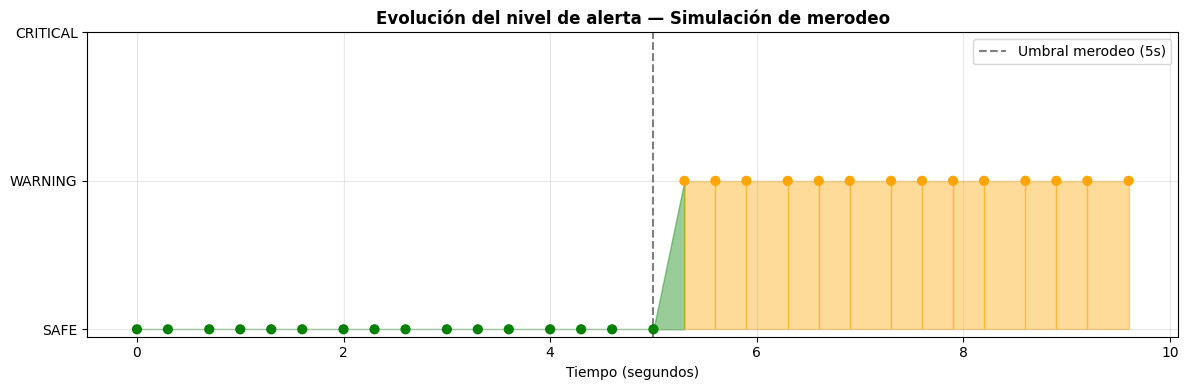


Merodeo detectado por primera vez en t=5.3s (frame 16)


In [14]:
engine_merodeo = SuspiciousBehaviorEngine()
T0 = 1000.0
N_FRAMES = 30   # ~10 segundos a 3fps

resultados = []
for f in range(N_FRAMES):
    t = T0 + f * 0.33
    # Persona casi quieta: ruido de ±4 px
    n = np.random.randint(-4, 5, 4)
    dets = [{"bbox": [200+n[0], 150+n[1], 280+n[2], 400+n[3]],
             "class_id": 0, "class_name": "person", "confidence": 0.88}]
    img_bg = np.full((480, 640, 3), 150, dtype=np.uint8)
    r = engine_merodeo.analyze(dets, (480, 640, 3), image=img_bg, timestamp=t)
    resultados.append({"t": round(t - T0, 1), "frame": f, "scenario": r["scenario_key"],
                       "level": r["risk_level"]})

# Graficar la evolución del nivel de alerta a lo largo del tiempo
level_num = {"SAFE": 0, "WARNING": 1, "CRITICAL": 2}
level_color = {"SAFE": "green", "WARNING": "orange", "CRITICAL": "red"}

tiempos   = [r["t"] for r in resultados]
niveles   = [level_num[r["level"]] for r in resultados]
colores   = [level_color[r["level"]] for r in resultados]

fig, ax = plt.subplots(figsize=(12, 4))
for i in range(len(tiempos)-1):
    ax.fill_between([tiempos[i], tiempos[i+1]], [niveles[i], niveles[i+1]], alpha=0.4,
                    color=colores[i])
ax.scatter(tiempos, niveles, c=colores, zorder=5, s=40)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["SAFE", "WARNING", "CRITICAL"])
ax.set_xlabel("Tiempo (segundos)")
ax.set_title("Evolución del nivel de alerta — Simulación de merodeo", fontweight="bold")
ax.axvline(x=5.0, color="black", linestyle="--", alpha=0.5, label="Umbral merodeo (5s)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Resumen
cambio = next((r for r in resultados if r["scenario"] == "merodeo"), None)
if cambio:
    print(f"\nMerodeo detectado por primera vez en t={cambio['t']}s (frame {cambio['frame']})")
else:
    print("Merodeo no detectado en esta simulación")

## 8 — Test con imágenes reales

In [15]:
def run_security_pipeline(image_path, conf_override=None, show=True, engine_instance=None):
    """
    Pipeline completo: carga imagen → detecta → analiza → visualiza.
    
    NOTA: Para análisis temporal real (merodeo, seguimiento) reutiliza
    el mismo engine_instance entre llamadas consecutivas.
    """
    if not os.path.exists(image_path):
        print(f"ERROR: no se encuentra {image_path}")
        return None, None

    image = cv2.imread(image_path)
    if image is None:
        print(f"ERROR: no se pudo leer {image_path}")
        return None, None

    if conf_override is not None:
        saved_conf = security_detector.conf_threshold
        security_detector.conf_threshold = conf_override

    t0   = time.time()
    dets = security_detector.detect(image)
    dt   = (time.time() - t0) * 1000

    if conf_override is not None:
        security_detector.conf_threshold = saved_conf

    eng = engine_instance if engine_instance is not None else SuspiciousBehaviorEngine()
    r   = eng.analyze(dets, image.shape, image=image, timestamp=time.time())

    print(f"Imagen:   {image_path} ({image.shape[1]}x{image.shape[0]})")
    print(f"Tiempo:   {dt:.1f} ms")
    print(f"Objetos detectados: {len(dets)}")
    for d in dets:
        print(f"  [{d['class_id']:2d}] {d['class_name']:12s} conf={d['confidence']:.3f}  bbox={d['bbox']}")
    if r['stats']['iluminacion']:
        luz = r['stats']['iluminacion']
        print(f"Iluminación: {luz['nivel_luz']} ({luz['brightness']}/255) — "
              f"{'OSCURO' if luz['is_dark'] else 'OK'}")
    print(f"Resultado: [{r['risk_level']}] {r['titulo']}")
    print(f"Acción:    {r['accion']}")

    if show:
        draw_security_analysis(image, dets, r)

    return dets, r

print("Pipeline de seguridad listo")

Pipeline de seguridad listo


Imagen:   calle1.jpg (640x480)
Tiempo:   282.0 ms
Objetos detectados: 0
Iluminación: normal (98.0/255) — OK
Resultado: [SAFE] Situación normal
Acción:    Continuar monitoreo.


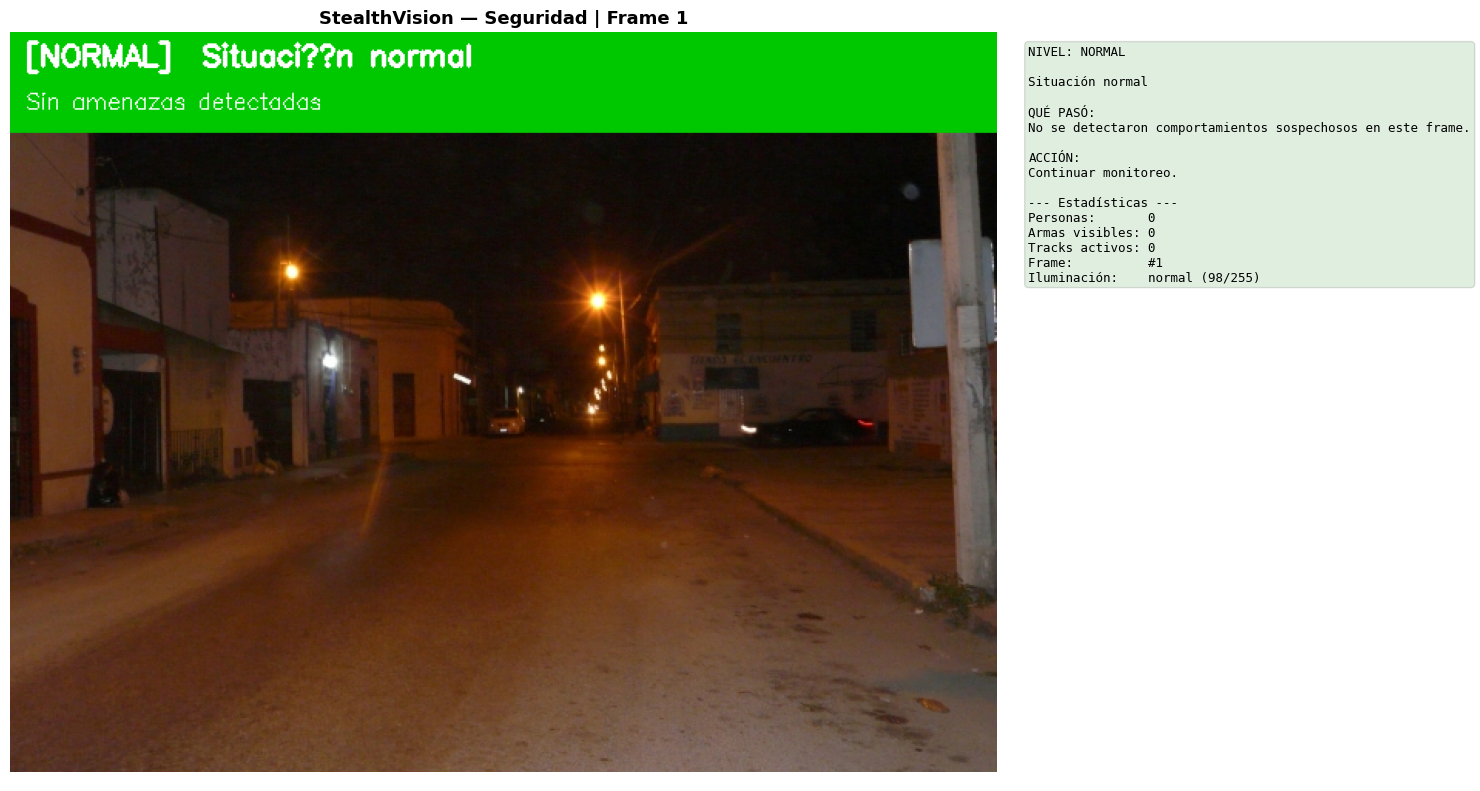

In [16]:
# --- Probar con calle1.jpg (imagen del proyecto) ---
# El modelo detectará personas. Si hay cuchillo/tijeras visible → CRITICAL
# Si hay varias personas juntas → posible confrontación o grupo
engine.reset()  # Reiniciar estado temporal
dets1, r1 = run_security_pipeline("calle1.jpg")

Imagen:   calle3oscura.jpg (1280x868)
Tiempo:   253.8 ms
Objetos detectados: 0
Iluminación: tenue (81.0/255) — OSCURO
Resultado: [SAFE] Situación normal
Acción:    Continuar monitoreo.


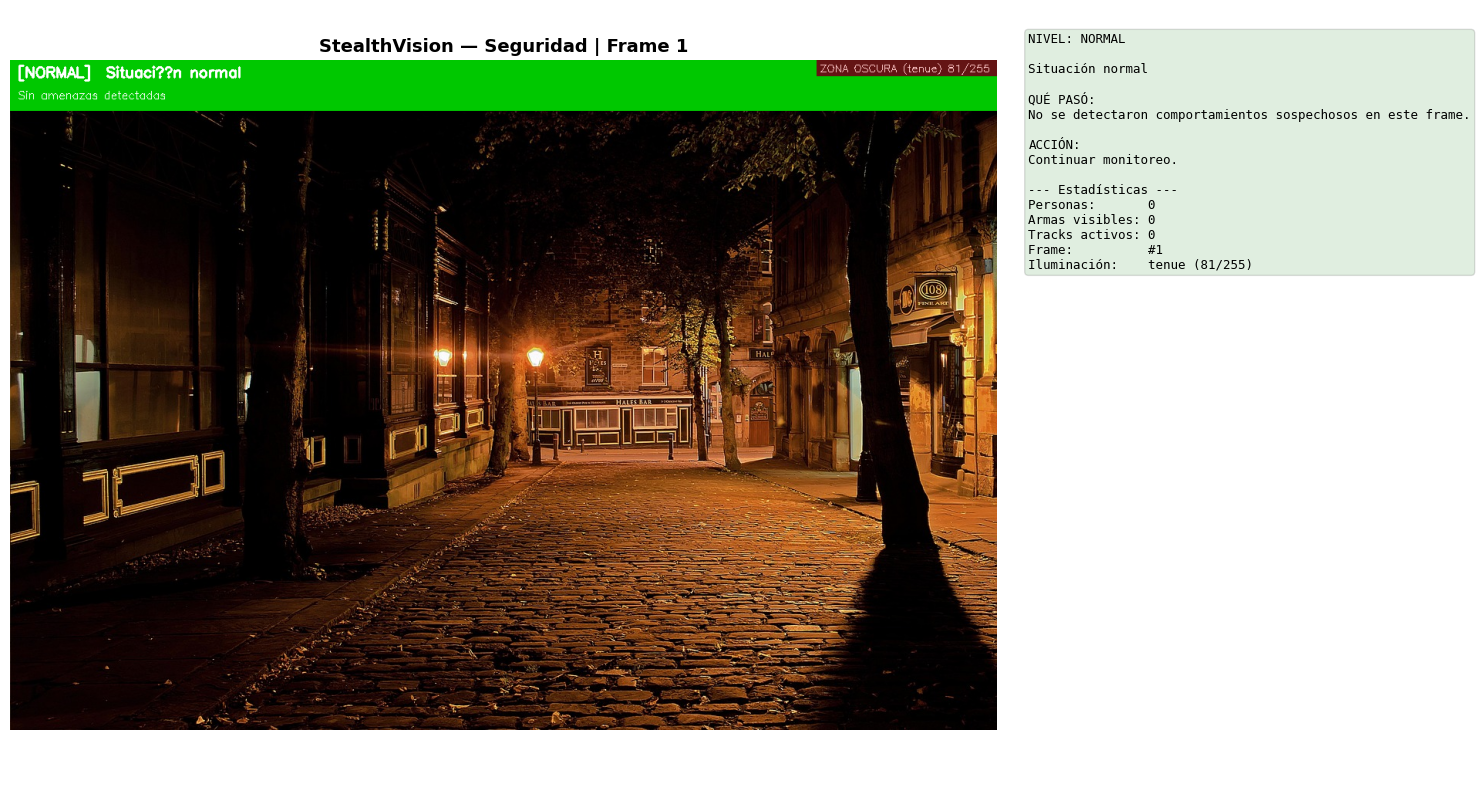

In [17]:
# --- Probar con imagen oscura ---
engine.reset()
dets2, r2 = run_security_pipeline("calle3oscura.jpg")

Imagen:   pruebasospechosa.jpg (816x1456)
Tiempo:   248.8 ms
Objetos detectados: 19
  [ 0] person       conf=0.875  bbox=[171, 337, 641, 1169]
  [ 0] person       conf=0.787  bbox=[622, 217, 814, 1078]
  [ 0] person       conf=0.731  bbox=[310, 0, 499, 357]
  [ 0] person       conf=0.688  bbox=[155, 1107, 599, 1455]
  [ 0] person       conf=0.747  bbox=[458, 111, 682, 667]
  [ 0] person       conf=0.588  bbox=[628, 17, 814, 299]
  [ 0] person       conf=0.656  bbox=[190, 112, 397, 504]
  [ 0] person       conf=0.688  bbox=[493, 1003, 787, 1455]
  [ 0] person       conf=0.614  bbox=[1, 61, 226, 489]
  [ 0] person       conf=0.411  bbox=[154, 0, 295, 251]
  [ 0] person       conf=0.562  bbox=[0, 258, 199, 710]
  [ 0] person       conf=0.417  bbox=[523, 0, 668, 223]
  [ 0] person       conf=0.554  bbox=[0, 478, 141, 945]
  [ 0] person       conf=0.476  bbox=[0, 948, 302, 1455]
  [ 0] person       conf=0.401  bbox=[0, 480, 143, 1156]
  [ 0] person       conf=0.454  bbox=[719, 618, 814, 139

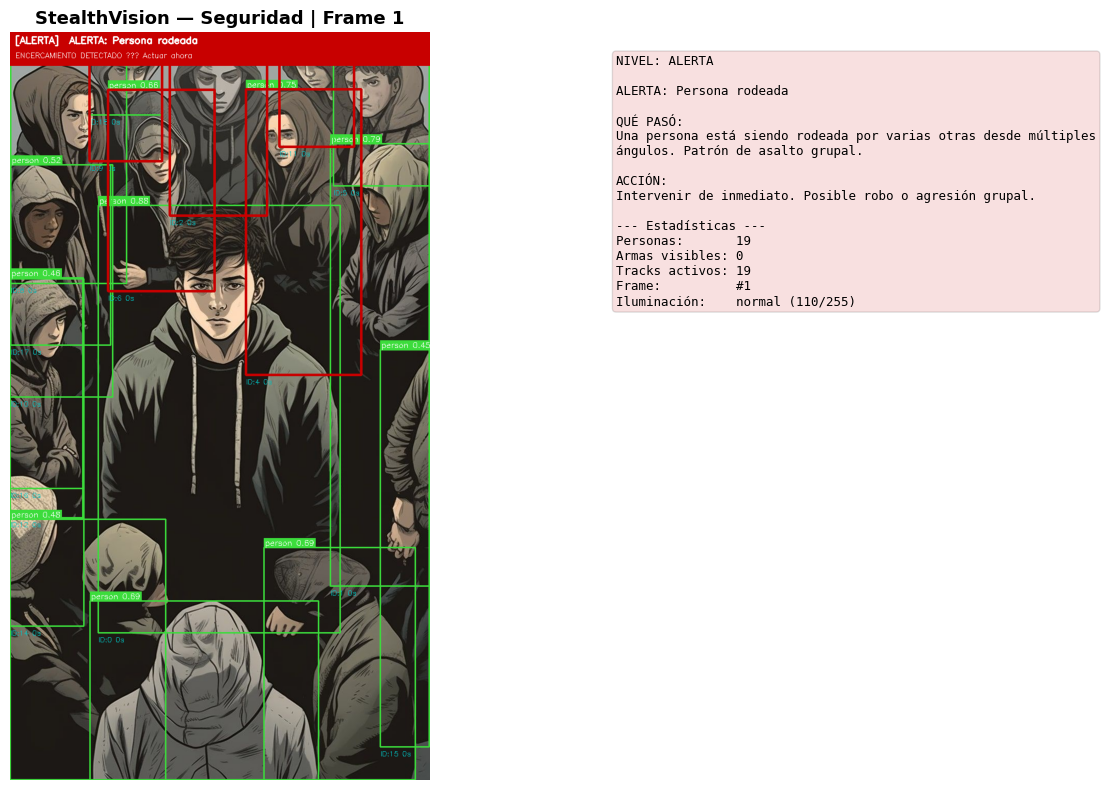

In [20]:
# --- Prueba con imagen personalizada ---
# Cambia IMAGEN_PRUEBA por la ruta que quieras
IMAGEN_PRUEBA = "pruebasospechosa.jpg"   # ← cambia aquí
CONF_PRUEBA   = 0.35           # Más bajo = más sensible

engine.reset()
dets_custom, r_custom = run_security_pipeline(IMAGEN_PRUEBA, conf_override=CONF_PRUEBA)

## 9 — Análisis de video en tiempo real

Esta celda es la más importante para la integración con Unreal Engine.
Procesa un video frame por frame, **manteniendo el estado temporal** del tracker entre frames.

**La diferencia clave con el análisis de imágenes individuales:**
- Cada frame alimenta el mismo `engine` → las identidades se mantienen
- Una persona quieta acumula tiempo hasta disparar `merodeo`
- Los tracks desaparecen si la persona sale de cámara por >1.5 segundos

Video:     rara1.mp4
FPS:       28.0
Frames:    415
Duración:  14.8 segundos
Frame   45 | t=1.6s | [SAFE] situacion_normal          | 2 personas | 309ms


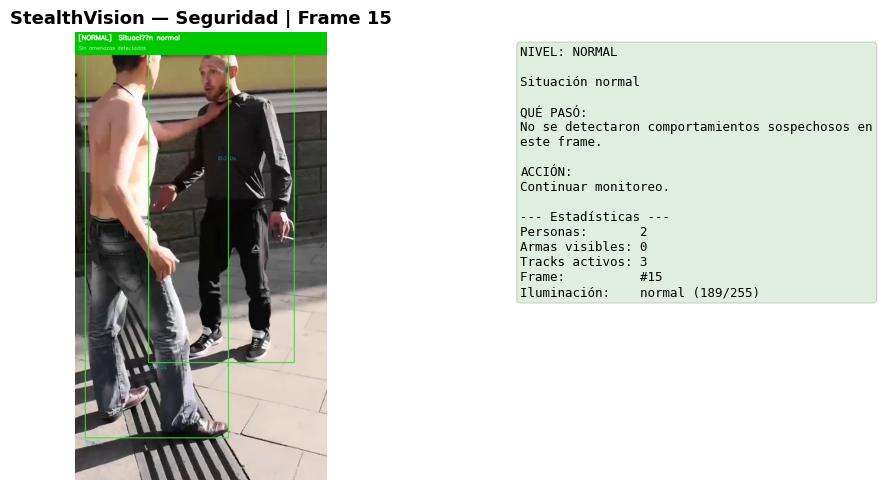

Frame   90 | t=3.2s | [SAFE] situacion_normal          | 1 personas | 264ms


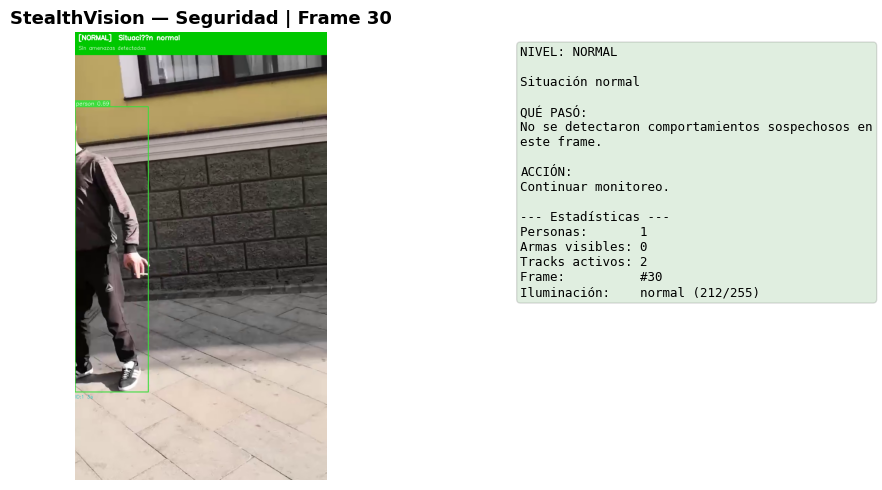

Frame  135 | t=4.8s | [SAFE] situacion_normal          | 0 personas | 259ms


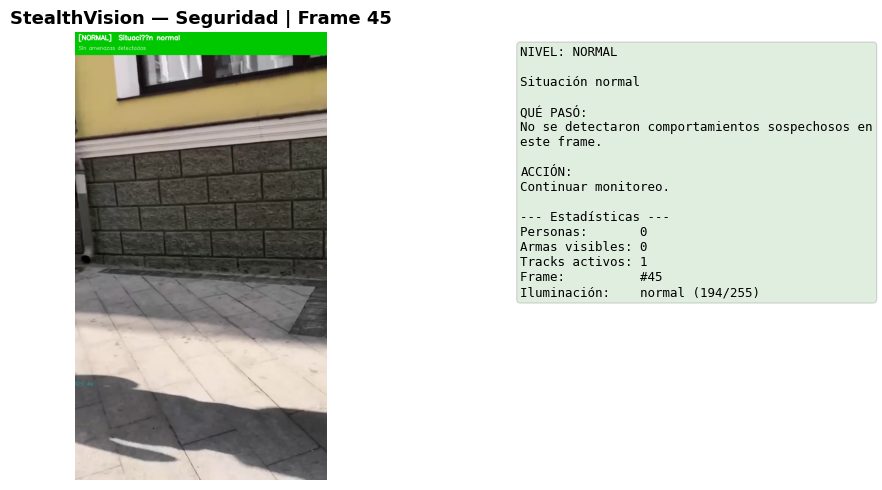

Frame  180 | t=6.4s | [SAFE] situacion_normal          | 3 personas | 263ms


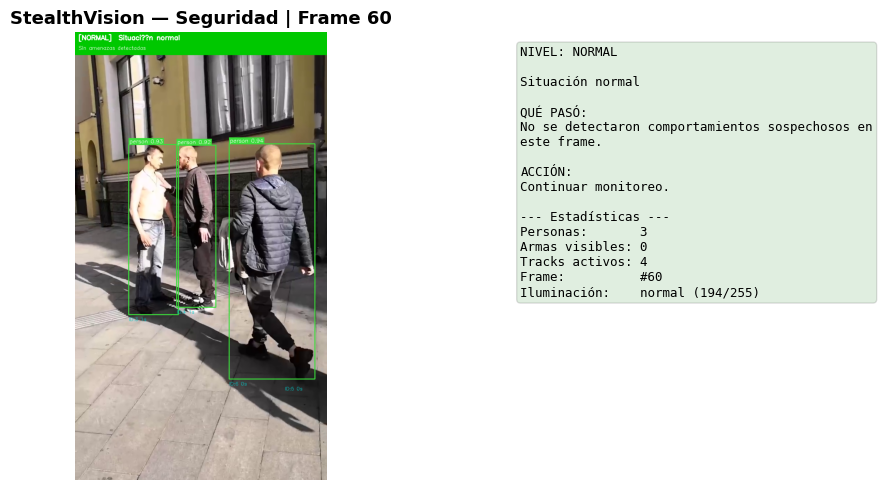


=== Resumen del video ===
Frames analizados: 60

Distribución de niveles:
  CRITICAL  :    1 frames (1.7%)
  SAFE      :   59 frames (98.3%)

Escenarios detectados:
  situacion_normal              : 59 frames
  confrontacion                 : 1 frames


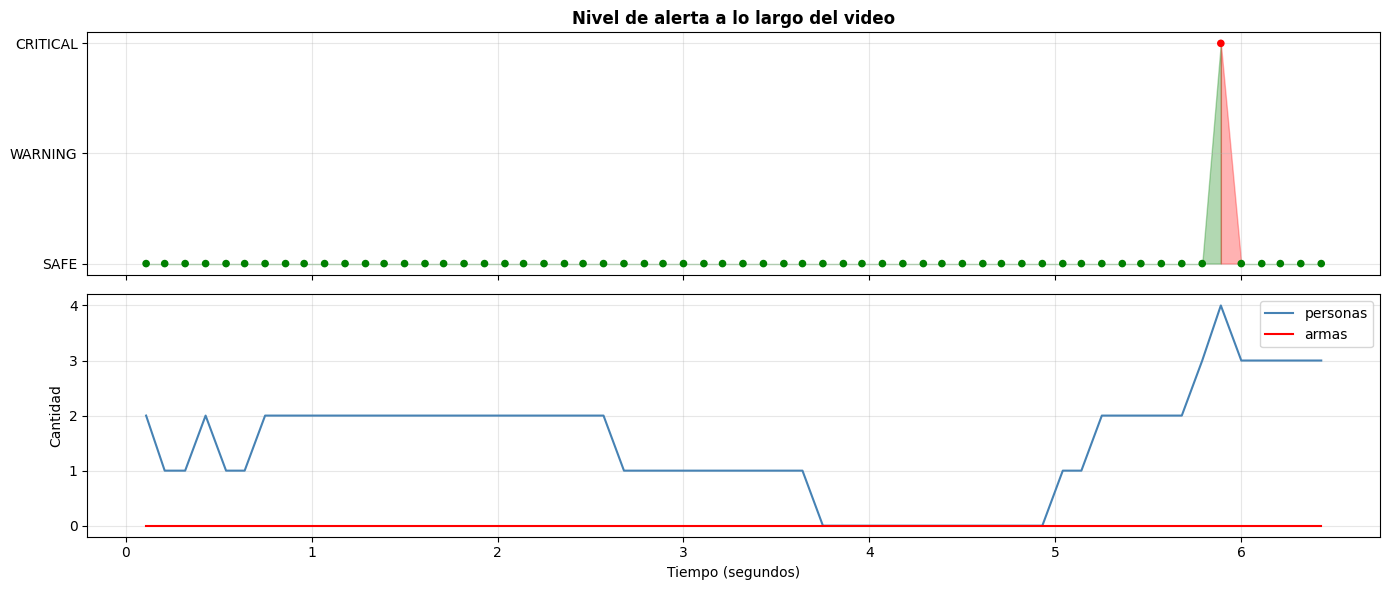

In [24]:
VIDEO_PATH  = "rara1.mp4"   # ← cambia aquí
MAX_FRAMES  = 60                  # Frames a analizar (None = todo el video)
SAMPLE_RATE = 3                   # Analizar 1 de cada N frames (velocidad vs precisión)
SHOW_EVERY  = 15                  # Mostrar imagen anotada cada N frames analizados

if not os.path.exists(VIDEO_PATH):
    print(f"Video no encontrado: {VIDEO_PATH}")
    print("Asigna VIDEO_PATH a tu archivo de video para usar esta celda.")
else:
    video_engine = SuspiciousBehaviorEngine()  # Motor persistente para todo el video
    cap = cv2.VideoCapture(VIDEO_PATH)
    fps_orig    = cap.get(cv2.CAP_PROP_FPS)
    total_orig  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_s  = total_orig / fps_orig if fps_orig > 0 else 0

    print(f"Video:     {VIDEO_PATH}")
    print(f"FPS:       {fps_orig:.1f}")
    print(f"Frames:    {total_orig}")
    print(f"Duración:  {duration_s:.1f} segundos")

    frame_count    = 0
    analyzed_count = 0
    results        = []
    frame_start    = time.time()

    while True:
        ret, frame = cap.read()
        if not ret: break
        frame_count += 1

        if frame_count % SAMPLE_RATE != 0:
            continue

        # Timestamp real del frame en el video
        frame_ts = frame_count / fps_orig if fps_orig > 0 else time.time()

        t0   = time.time()
        dets = security_detector.detect(frame)
        r    = video_engine.analyze(dets, frame.shape, image=frame, timestamp=frame_ts)
        dt   = (time.time() - t0) * 1000

        results.append({
            "frame":    frame_count,
            "ts":       round(frame_ts, 2),
            "level":    r["risk_level"],
            "scenario": r["scenario_key"],
            "personas": r["stats"]["personas"],
            "armas":    r["stats"]["armas_visibles"],
            "tracks":   r["stats"]["tracks_activos"],
            "ms":       round(dt, 1),
        })
        analyzed_count += 1

        # Mostrar frame anotado periódicamente
        if analyzed_count % SHOW_EVERY == 0:
            print(f"Frame {frame_count:4d} | t={frame_ts:.1f}s | [{r['risk_level']}] "
                  f"{r['scenario_key']:25s} | {r['stats']['personas']} personas | {dt:.0f}ms")
            out_frame = draw_security_analysis(frame, dets, r, figsize=(12, 5))

        if MAX_FRAMES and analyzed_count >= MAX_FRAMES:
            break

    cap.release()

    # ---- Resumen estadístico ----
    print(f"\n=== Resumen del video ===")
    print(f"Frames analizados: {analyzed_count}")

    from collections import Counter
    level_counts    = Counter(r["level"]    for r in results)
    scenario_counts = Counter(r["scenario"] for r in results)

    print(f"\nDistribución de niveles:")
    for lvl in ["CRITICAL", "WARNING", "SAFE"]:
        pct = level_counts.get(lvl, 0) / analyzed_count * 100
        print(f"  {lvl:<10}: {level_counts.get(lvl, 0):4d} frames ({pct:.1f}%)")

    print(f"\nEscenarios detectados:")
    for sc, cnt in scenario_counts.most_common():
        print(f"  {sc:<30}: {cnt} frames")

    # ---- Gráfico de línea temporal ----
    level_num   = {"SAFE": 0, "WARNING": 1, "CRITICAL": 2}
    level_color = {"SAFE": "green", "WARNING": "orange", "CRITICAL": "red"}
    tiempos = [r["ts"] for r in results]
    niveles = [level_num[r["level"]] for r in results]
    colores = [level_color[r["level"]] for r in results]

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    # Panel 1: nivel de alerta
    axes[0].scatter(tiempos, niveles, c=colores, s=20, zorder=5)
    for i in range(len(tiempos)-1):
        axes[0].fill_between([tiempos[i], tiempos[i+1]], [niveles[i], niveles[i+1]],
                              alpha=0.3, color=colores[i])
    axes[0].set_yticks([0, 1, 2])
    axes[0].set_yticklabels(["SAFE", "WARNING", "CRITICAL"])
    axes[0].set_title("Nivel de alerta a lo largo del video", fontweight="bold")
    axes[0].grid(True, alpha=0.3)

    # Panel 2: personas detectadas
    axes[1].plot(tiempos, [r["personas"] for r in results], color="steelblue", lw=1.5, label="personas")
    axes[1].plot(tiempos, [r["armas"] for r in results], color="red",      lw=1.5, label="armas")
    axes[1].set_ylabel("Cantidad")
    axes[1].set_xlabel("Tiempo (segundos)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 10 — Probar la API REST

La API es la interfaz que Unreal Engine usa para enviar frames y recibir resultados.

**Flujo Unreal Engine → Backend:**
```
UE captura frame → renderiza a imagen → POST /security?session_id=cam1
                                               ↓
                               Backend: detecta + analiza + devuelve JSON
                                               ↓
                           UE recibe risk_level → activa alarma / NPC / overlay
```

Primero inicia el servidor: `python main.py`

In [ ]:
import requests, json

API_URL = "http://localhost:8000"

try:
    r = requests.get(f"{API_URL}/health", timeout=3)
    print("Health check:")
    print(json.dumps(r.json(), indent=2, ensure_ascii=False))
except Exception as e:
    print(f"Servidor no disponible: {e}")
    print("Ejecuta primero: python main.py")

In [ ]:
# Test del endpoint /security con una imagen real
TEST_IMG    = "calle1.jpg"
SESSION_ID  = "cuadernillo_test"

try:
    # 1. Reiniciar sesión (equivale a nueva escena en UE)
    r_reset = requests.post(f"{API_URL}/security/reset?session_id={SESSION_ID}", timeout=5)
    print("Reset:", r_reset.json())

    # 2. Enviar frame y analizar
    with open(TEST_IMG, "rb") as f:
        r_sec = requests.post(
            f"{API_URL}/security",
            params={"session_id": SESSION_ID},
            files={"file": f},
            timeout=15,
        )

    result = r_sec.json()
    print(f"\nResultado /security para {TEST_IMG}:")
    print(f"  risk_level:   {result['risk_level']}")
    print(f"  scenario_key: {result['scenario_key']}")
    print(f"  titulo:       {result['titulo']}")
    print(f"  accion:       {result['accion']}")
    print(f"  tracks:       {len(result.get('tracks', []))} personas rastreadas")
    print(f"  inference_ms: {result['inference_time_ms']}")
    print(f"  stats:        {result['stats']}")

except Exception as e:
    print(f"Error: {e}")

In [ ]:
# Obtener imagen anotada del endpoint /security_visual
from IPython.display import Image as IPImage
import io

try:
    with open(TEST_IMG, "rb") as f:
        r_vis = requests.post(
            f"{API_URL}/security_visual",
            params={"session_id": SESSION_ID},
            files={"file": f},
            timeout=15,
        )

    # Mostrar imagen anotada
    img_arr = np.frombuffer(r_vis.content, np.uint8)
    img_vis = cv2.imdecode(img_arr, cv2.IMREAD_COLOR)
    plt.figure(figsize=(10, 7))
    plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Respuesta de /security_visual — {TEST_IMG}", fontweight="bold")
    plt.show()

except Exception as e:
    print(f"Error en /security_visual: {e}")

In [ ]:
# Ver estado de todas las sesiones activas en el servidor
try:
    r_sessions = requests.get(f"{API_URL}/security/sessions", timeout=5)
    print("Sesiones activas:")
    print(json.dumps(r_sessions.json(), indent=2, ensure_ascii=False))
except Exception as e:
    print(f"Error: {e}")

## 11 — Integración con Unreal Engine

### Endpoints disponibles

| Endpoint | Método | Para qué |
|---|---|---|
| `/security?session_id=cam1` | POST | Frame → JSON con nivel + tracks |
| `/security_visual?session_id=cam1` | POST | Frame → Imagen JPEG anotada |
| `/security/reset?session_id=cam1` | POST | Reiniciar tracking (nueva escena) |
| `/security/sessions` | GET | Estado de todas las cámaras activas |

### JSON de respuesta de `/security`

```json
{
  "risk_level": "CRITICAL",
  "scenario_key": "arma_detectada",
  "titulo": "ALERTA: Arma blanca visible",
  "descripcion": "Se detectó un arma blanca ...",
  "accion": "Activar protocolo de seguridad.",
  "consejo": "OBJETO PELIGROSO DETECTADO — Intervenir ahora",
  "involucrados": [
    {"clase": "person", "confianza": 0.91, "bbox": [200, 150, 280, 400]},
    {"clase": "knife",  "confianza": 0.78, "bbox": [210, 200, 240, 240]}
  ],
  "tracks": [
    {"track_id": 0, "loitering": false, "age_seconds": 2.3, "bbox": [200, 150, 280, 400]}
  ],
  "stats": {
    "personas": 1, "armas_visibles": 1, "tracks_activos": 1,
    "frame": 42, "iluminacion": {"is_dark": false, ...}
  },
  "inference_time_ms": 18.4
}
```

### Lógica sugerida en Blueprint / C++ de Unreal Engine

```
Si risk_level == "CRITICAL"  → Activar alarma roja + NPC guardia
Si risk_level == "WARNING"   → Activar cámara de seguimiento + alerta amarilla
Si risk_level == "SAFE"      → Monitoreo pasivo

Si scenario_key == "merodeo" → Highlight persona en el mapa
Si scenario_key == "arma_detectada" → Freeze escena + alerta máxima
```

### Patrón de uso multi-cámara

```python
# Cámara 1
POST /security?session_id=cam_entrada   # mantiene tracking de la entrada

# Cámara 2
POST /security?session_id=cam_pasillo   # tracking independiente del pasillo

# Cada cámara es una sesión independiente con su propio PersonTracker
```

## Resumen del sistema

```
FRAME DE VIDEO / UNREAL ENGINE
│
├── RTDetrDetector.detect(frame)
│   └── Clases: person, knife, scissors, backpack, handbag
│   └── Modelo: RT-DETR L ONNX (rtdetr-l.onnx) — 132 MB
│   └── Tiempo: ~10-25 ms/frame (GPU)
│
├── PersonTracker.update(persons, timestamp)
│   └── IoU matching entre frames consecutivos
│   └── Mantiene historial de posición de cada persona
│   └── Detecta merodeo: quieto > 5 segundos
│
├── analyze_lighting(frame)
│   └── Percentil 75 del brillo — zonas oscuras
│
└── SuspiciousBehaviorEngine.analyze()
    └── Prioridad: arma > encercamiento > confrontación > merodeo > oscuridad > grupo
    └── Devuelve: risk_level, scenario_key, titulo, accion, tracks, stats
```

**Escenarios CRITICAL → acción inmediata:**
- Arma blanca detectada cerca de persona
- Persona siendo rodeada por 3+ individuos
- Dos personas en contacto físico (posible pelea)

**Escenarios WARNING → vigilar:**
- Persona inmóvil > 5 segundos (merodeo)
- Actividad humana en zona oscura
- Concentración inusual de personas